✅ 找到 ZIP 文件，正在解压...
🎉 解压完成！
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🚀 模型开始训练 (预计 10-15 分钟)...
Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 600ms/step - accuracy: 0.7920 - loss: 0.4506 - val_accuracy: 0.8418 - val_loss: 0.3132
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 556ms/step - accuracy: 0.8787 - loss: 0.2850 - val_accuracy: 0.8965 - val_loss: 0.2533
Epoch 3/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 545ms/step - accuracy: 0.8998 - loss: 0.2496 - val_accuracy: 0.8965 - val_loss: 0.2493
Epoch 4/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 543ms/step - accuracy: 0.9200 - loss: 0.2044 - val_accuracy: 0.9108 - val_loss: 0.1982
Epoch 5/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 546ms/step - accuracy: 0.9212 - loss: 0.2018 - val_accuracy: 0.9319 - val_loss: 0.1705
Epoch 6/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 546ms/step - accuracy: 0.9264 - loss: 0.1940 - val_accuracy: 0.9271 - val_loss: 0.1794
Epoch 7/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 72s 549ms/step - accuracy: 0.9322 - loss: 0.1791 - val_accuracy: 0.9118 - val_loss: 0.2138
Epoch 8/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 552ms/step -

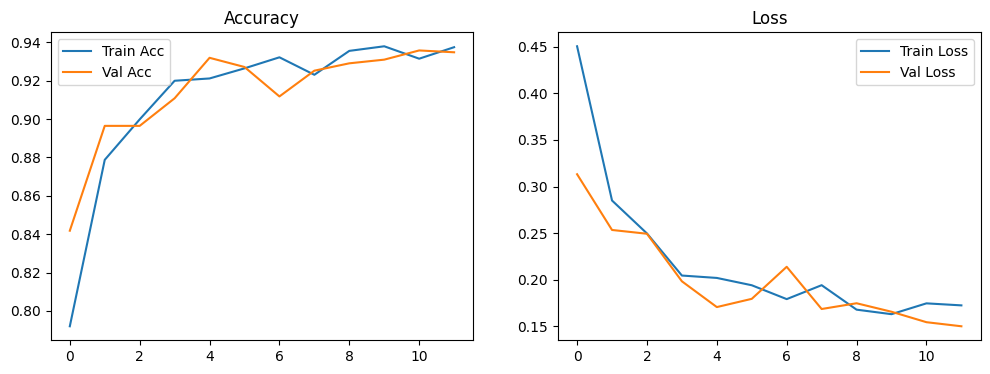

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step

--- 分类报告 ---
              precision    recall  f1-score   support

      Normal       0.97      0.64      0.77       234
   Pneumonia       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624



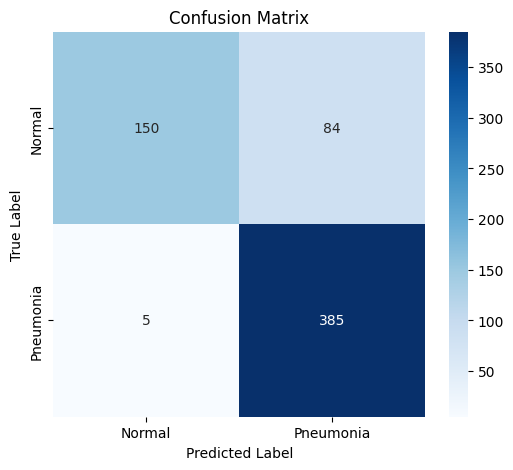

In [13]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ==========================================
# 1. 强制解压 (使用你提供的精准路径)
# ==========================================
zip_path = '/content/drive/MyDrive/kaggle_data/pneumonia_dataset.zip'
extract_path = '/content/dataset_temp'

if os.path.exists(zip_path):
    print("✅ 找到 ZIP 文件，正在解压...")
    !rm -rf {extract_path}
    !mkdir -p {extract_path}
    !unzip -o -q "{zip_path}" -d {extract_path}
    print("🎉 解压完成！")
else:
    raise FileNotFoundError(f"❌ 依然找不到文件: {zip_path}，请确认左侧文件栏路径是否一致。")

# ==========================================
# 2. 路径对齐
# ==========================================
# 自动定位包含 train 的实际目录
base_path = None
for root, dirs, files in os.walk(extract_path):
    if 'train' in dirs and 'test' in dirs:
        base_path = root
        break

if not base_path:
    raise ValueError("❌ 压缩包结构异常，未找到 train/test 文件夹。")

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# ==========================================
# 3. 数据准备 (作业要求：8:2 划分验证集)
# ==========================================
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 关键：重新划分验证集
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

# ==========================================
# 4. 模型构建与训练
# ==========================================
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n🚀 模型开始训练 (预计 10-15 分钟)...")
history = model.fit(train_gen, epochs=12, validation_data=val_gen)

# ==========================================
# 5. 生成实验报告图表
# ==========================================
# 5.1 准确率/损失曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 5.2 评价指标与混淆矩阵
test_gen.reset()
preds = model.predict(test_gen)
y_pred = (preds > 0.5).astype(int)
y_true = test_gen.classes

print("\n--- 分类报告 ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()